# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Ekam Nijjar`  
**SFU ID:** `301457886`  
**Date:** `July 1st, 2026`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [3]:
df_ab = pd.read_csv('phigma_ab_study.csv')

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NaN,5,1,1,0,38,17.91


In [4]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,1323,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,U10149,control,desktop,NaN,NaN,EU,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,593,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [5]:
# Missing values
df_ab.isnull().sum()


user_id                                  0
ab_group                                 0
device_type                              0
account_age_days                         0
prior_whiteboard_sessions                0
plan_region                            677
num_collaborators                        0
feature_tour_completed                   0
templates_used                           0
ai_suggestions_used                      0
whiteboard_actions_per_session           0
avg_whiteboard_session_duration_min      0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


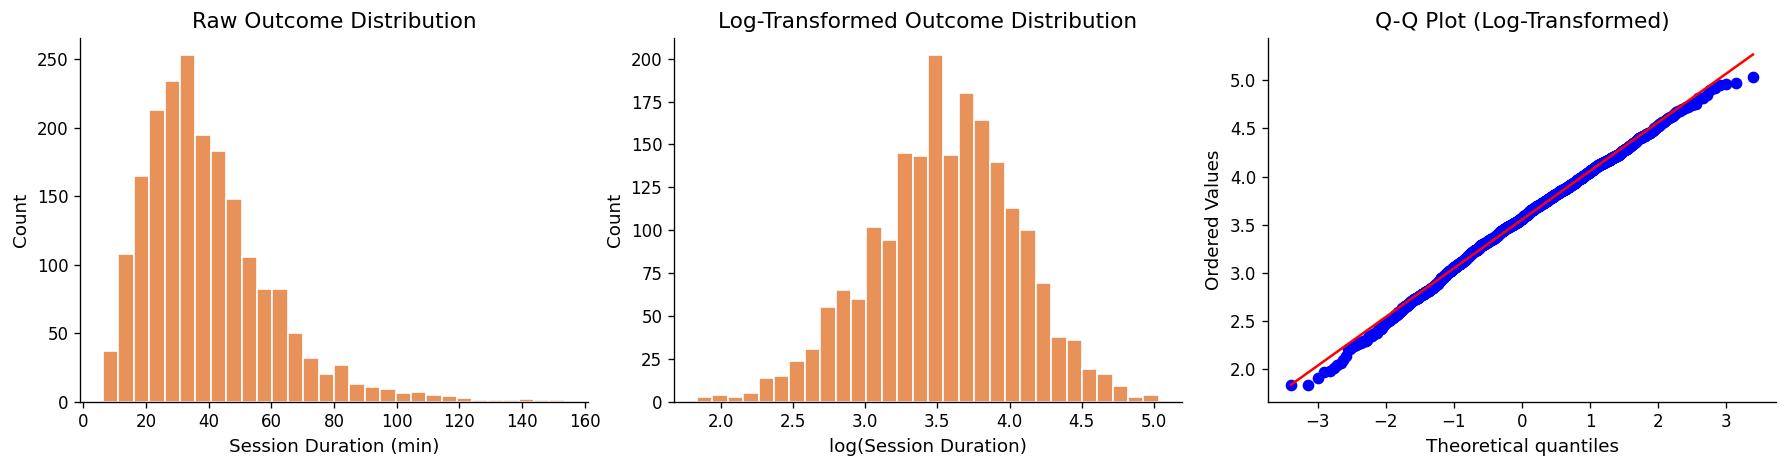

Raw skewness:          1.3758
Log-transformed skewness: -0.2133


In [ ]:
y = df_ab['avg_whiteboard_session_duration_min']
log_y = np.log(y)

# 1. Normality & Transformation Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y, bins=30, color=ACCENT, edgecolor='white')
axes[0].set_title('Raw Outcome Distribution')
axes[0].set_xlabel('Session Duration (min)')
axes[0].set_ylabel('Count')

axes[1].hist(log_y, bins=30, color=ACCENT, edgecolor='white')
axes[1].set_title('Log-Transformed Outcome Distribution')
axes[1].set_xlabel('log(Session Duration)')
axes[1].set_ylabel('Count')

stats.probplot(log_y, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Log-Transformed)')

plt.tight_layout()
plt.show()

# 2. Statistical Diagnostics
print(f"Raw skewness:          {stats.skew(y):.4f}")
print(f"Log-transformed skewness: {stats.skew(log_y):.4f}")


**✏️ Your interpretation (A1.1):**

The raw outcome () is right-skewed with a skewness of 1.38, indicating a long right tail driven by a small number of very long sessions. After applying a natural log transformation, the skewness drops to −0.21, which is very close to zero and reflects a nearly symmetric distribution. The Q-Q plot of the log-transformed outcome shows the quantiles falling tightly along the theoretical normal line, with only minor deviations at the tails, confirming approximate normality. I will use the log-transformed outcome in the OLS model, as the normality of residuals assumption is much better satisfied on that scale.


#### A1.2 — Examine the confounders

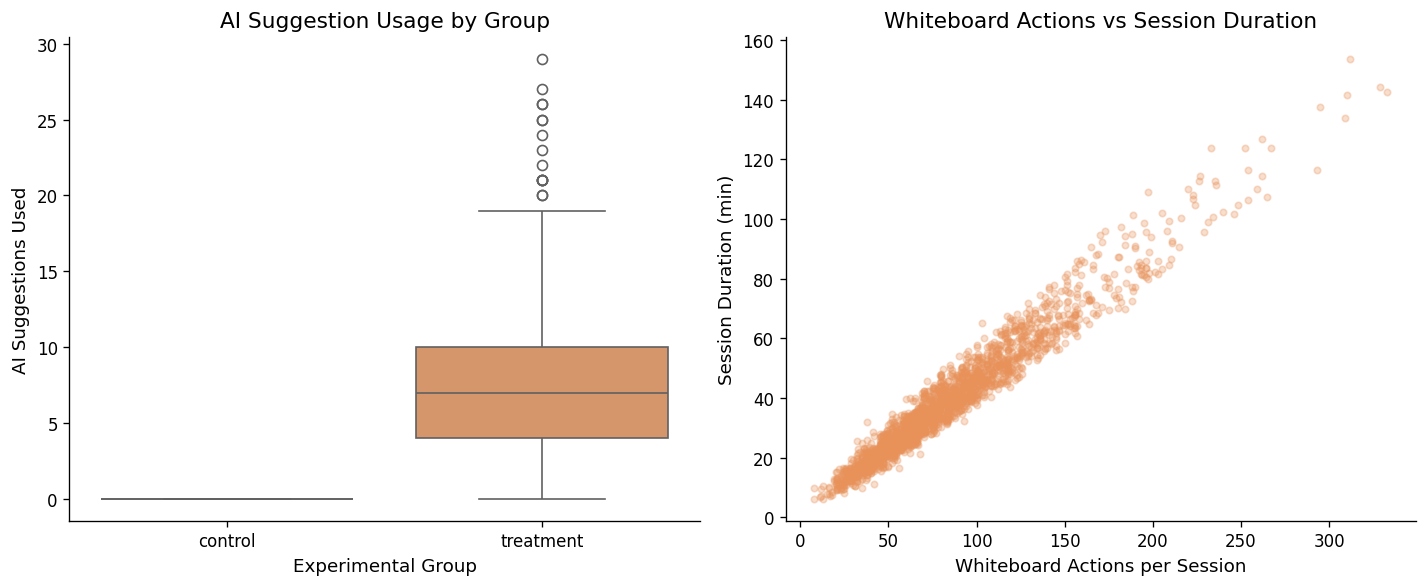

Correlation (whiteboard_actions_per_session vs outcome): 0.9737

AI suggestions used — descriptive stats by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [8]:
# 1. Visual Exploratory Data Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df_ab, x='ab_group', y='ai_suggestions_used',
    palette={'control': '#aec6cf', 'treatment': ACCENT}, ax=axes[0]
)
axes[0].set_title('AI Suggestion Usage by Group')
axes[0].set_xlabel('Experimental Group')
axes[0].set_ylabel('AI Suggestions Used')

axes[1].scatter(
    df_ab['whiteboard_actions_per_session'],
    df_ab['avg_whiteboard_session_duration_min'],
    alpha=0.3, color=ACCENT, s=15
)
axes[1].set_title('Whiteboard Actions vs Session Duration')
axes[1].set_xlabel('Whiteboard Actions per Session')
axes[1].set_ylabel('Session Duration (min)')

plt.tight_layout()
plt.show()

# 2. Statistical Analysis
corr = df_ab['whiteboard_actions_per_session'].corr(df_ab['avg_whiteboard_session_duration_min'])
print(f"Correlation (whiteboard_actions_per_session vs outcome): {corr:.4f}")
print()
print("AI suggestions used — descriptive stats by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))


**✏️ Your interpretation (A1.2):**

  ai_suggestions_used is zero for every control user and averages 7.33 in the treatment group, so it is basically just another name for the treatment itself. If we add it as a predictor, it overlaps almost perfectly with the group variable and ends up soaking up the treatment effect we are trying to measure. whiteboard_actions_per_session correlates 0.97 with the outcome, which means it is essentially measuring the same thing as session duration rather than explaining it. Including it would overlap heavily with the outcome and make the treatment coefficient unreliable. Both variables are dropped because they either restate the outcome or are results of the treatment, not characteristics users had beforehand.


#### A1.3 — Predictor distributions and relationships with outcome

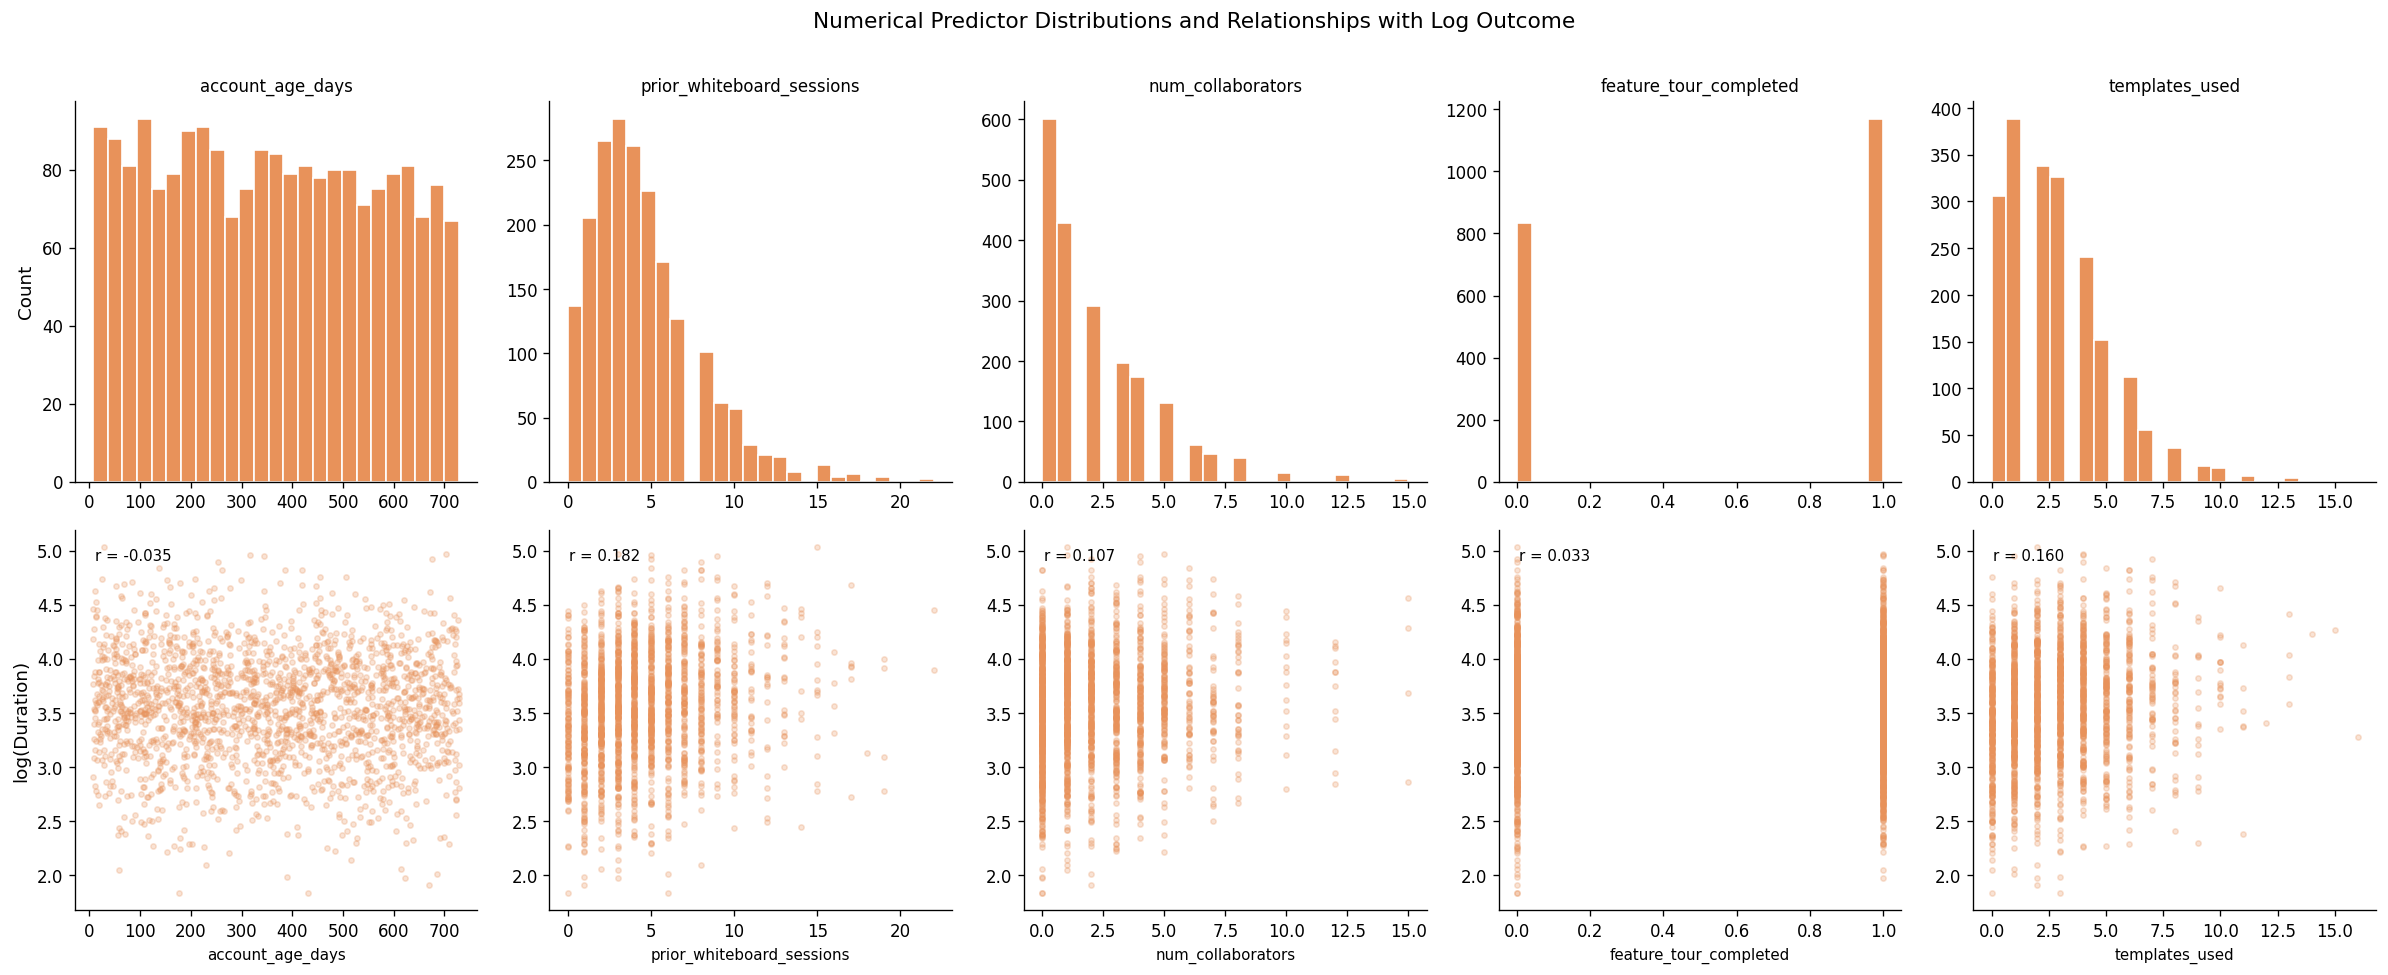

In [ ]:
num_predictors = ['account_age_days', 'prior_whiteboard_sessions', 'num_collaborators',
                  'feature_tour_completed', 'templates_used']
log_y = np.log(df_ab['avg_whiteboard_session_duration_min'])

n = len(num_predictors)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

for j, col in enumerate(num_predictors):
    # Top row: histogram
    axes[0, j].hist(df_ab[col], bins=25, color=ACCENT, edgecolor='white')
    axes[0, j].set_title(col, fontsize=10)
    axes[0, j].set_ylabel('Count' if j == 0 else '')

    # Bottom row: scatter vs log outcome
    corr = df_ab[col].corr(log_y)
    axes[1, j].scatter(df_ab[col], log_y, alpha=0.25, s=10, color=ACCENT)
    axes[1, j].set_xlabel(col, fontsize=9)
    axes[1, j].set_ylabel('log(Duration)' if j == 0 else '')
    axes[1, j].annotate(f'r = {corr:.3f}', xy=(0.05, 0.92),
                        xycoords='axes fraction', fontsize=9)

fig.suptitle('Numerical Predictor Distributions and Relationships with Log Outcome',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


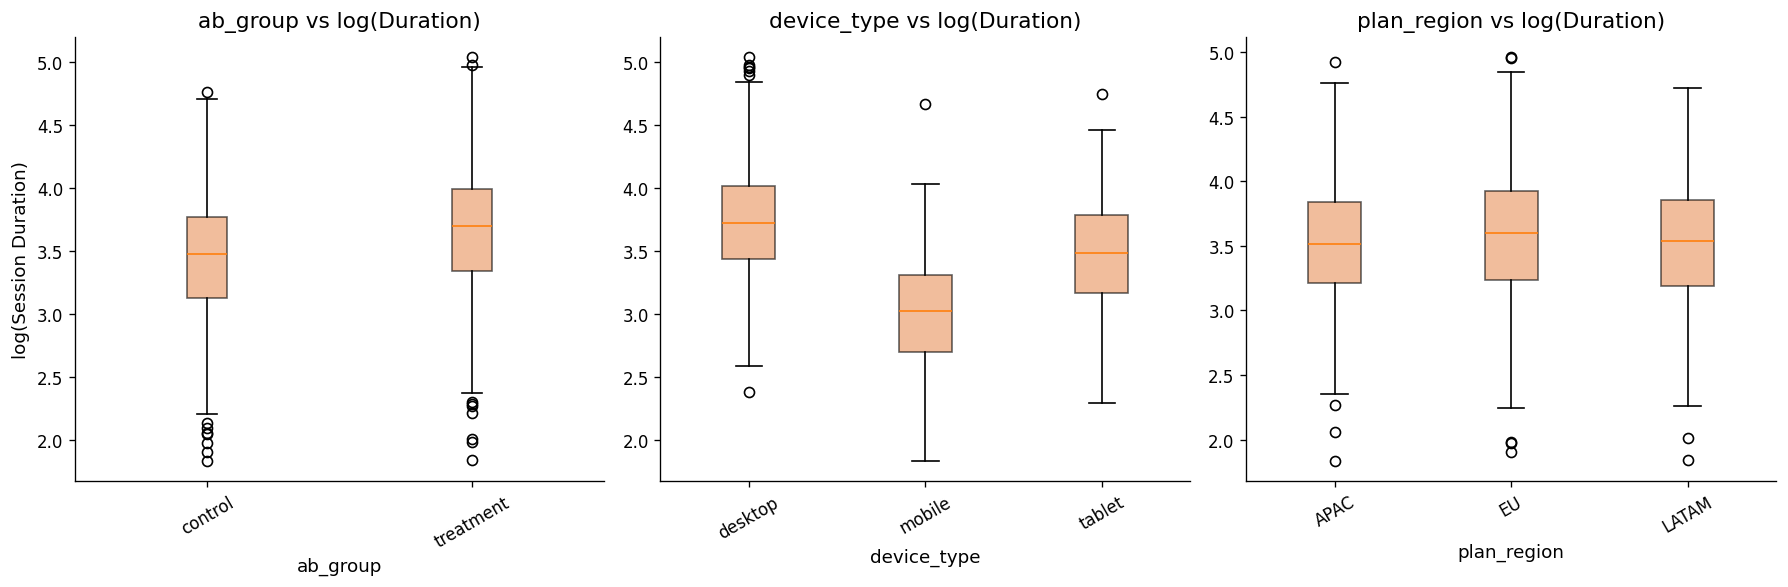

In [ ]:
cat_predictors = ['ab_group', 'device_type', 'plan_region']

n = len(cat_predictors)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

for j, col in enumerate(cat_predictors):
    levels = sorted(df_ab[col].dropna().unique())
    groups = [log_y[df_ab[col] == lvl] for lvl in levels]
    axes[j].boxplot(groups, labels=levels, patch_artist=True,
                    boxprops=dict(facecolor=ACCENT, alpha=0.6))
    axes[j].set_title(f'{col} vs log(Duration)')
    axes[j].set_xlabel(col)
    axes[j].set_ylabel('log(Session Duration)' if j == 0 else '')
    axes[j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**✏️ Your interpretation (A1.3):**

Among the numerical predictors, prior_whiteboard_sessions (r = 0.182), templates_used (r = 0.160), and num_collaborators (r = 0.107) show the strongest positive correlations with the log-transformed outcome, making them the most promising features for the model. account_age_days (r = -0.035) and feature_tour_completed (r = 0.033) have near-zero correlations and are unlikely to add much predictive power. prior_whiteboard_sessions and templates_used are both right-skewed and are good candidates for a log(x + 1) transformation before use as predictors. Among the categoricals, ab_group shows a visible upward median shift from control to treatment, confirming it captures the intervention effect, while device_type shows desktop sessions running longer than mobile, and plan_region looks broadly similar across regions. The two excluded variables are ai_suggestions_used (zero for all control users, so it is effectively a restatement of the treatment group) and whiteboard_actions_per_session (r = 0.97 with the outcome, a near-duplicate of what we are trying to predict).


### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
# 1. Encode Categorical Variables
df_ab['ab_group_bin'] = (df_ab['ab_group'] == 'treatment').astype(int)

device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device', drop_first=True)
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region', drop_first=True)

# 2. Perform Optional Transformations
df_ab['log_prior_whiteboard_sessions'] = np.log1p(df_ab['prior_whiteboard_sessions'])
df_ab['log_templates_used'] = np.log1p(df_ab['templates_used'])

# 3. Assemble Modeling Dataset
X = pd.concat([
    df_ab[['account_age_days', 'log_prior_whiteboard_sessions', 'num_collaborators',
           'feature_tour_completed', 'log_templates_used', 'ab_group_bin']],
    device_dummies,
    region_dummies,
], axis=1).astype(float)

y = np.log(df_ab['avg_whiteboard_session_duration_min'])

# 4. Quality Control
print(f'X shape: {X.shape}')
print(f'Missing values in X: {X.isnull().sum().sum()}')
print()
print(X.head())


X shape: (2000, 10)
Missing values in X: 0

   account_age_days  log_prior_whiteboard_sessions  num_collaborators  \
0             478.0                       1.609438                3.0   
1             633.0                       2.302585                1.0   
2             159.0                       2.397895                5.0   
3               7.0                       1.791759                1.0   
4              44.0                       1.386294                0.0   

   feature_tour_completed  log_templates_used  ab_group_bin  device_mobile  \
0                     1.0            0.000000           0.0            0.0   
1                     0.0            0.693147           0.0            0.0   
2                     1.0            0.693147           0.0            0.0   
3                     0.0            1.098612           0.0            0.0   
4                     1.0            1.791759           0.0            1.0   

   device_tablet  region_EU  region_LATAM  
0   

In [15]:
from scipy.stats import skew

for col in ['account_age_days', 'prior_whiteboard_sessions',
            'num_collaborators', 'templates_used']:
    print(f"{col}: skewness = {skew(df_ab[col]):.2f}")

account_age_days: skewness = 0.06
prior_whiteboard_sessions: skewness = 1.20
num_collaborators: skewness = 1.55
templates_used: skewness = 1.16


**Your interpretation (A2):**

The final feature matrix X contains the following columns:

- account_age_days: included as-is; near-zero skewness (0.06) means no transformation is needed.
- log_prior_whiteboard_sessions: log-transformed with np.log1p because prior_whiteboard_sessions is right-skewed (skewness 1.20) and contains zeros, where np.log would produce -inf.
- num_collaborators: included as-is; right-skewed (skewness 1.55) but kept on the raw scale as its correlation with the outcome is modest (r = 0.107).
- feature_tour_completed: included as-is; binary 0/1 flag, no transformation needed.
- log_templates_used: log-transformed with np.log1p because templates_used is right-skewed (skewness 1.16) and contains zeros.
- ab_group_bin: encoded as 1 = treatment, 0 = control; this is the key causal variable of interest.
- device_mobile, device_tablet: one-hot encoding of device_type with the first level (desktop) dropped to avoid the dummy-variable trap.
- region_EU, region_LATAM: one-hot encoding of plan_region with the first level (APAC) dropped to avoid the dummy-variable trap.

ai_suggestions_used and whiteboard_actions_per_session are excluded: the former is effectively a proxy for the treatment group (zero for all control users), and the latter is a near-duplicate of the outcome (r = 0.97).


### A3 — OLS Regression


In [18]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.362
Model:                                             OLS   Adj. R-squared:                  0.359
Method:                                  Least Squares   F-statistic:                     112.8
Date:                                 Sat, 27 Jun 2026   Prob (F-statistic):          7.47e-186
Time:                                         17:38:55   Log-Likelihood:                -1022.3
No. Observations:                                 2000   AIC:                             2067.
Df Residuals:                                     1989   BIC:                             2128.
Df Model:                                           10                                         
Covariance Type:                             nonrobust                                         
                                    coef

#### A3.1 — Interpret the model

In [20]:
# 1. Evaluate Model Fit
print(f"R-squared:          {model_ols.rsquared:.4f}")
print(f"Adj. R-squared:     {model_ols.rsquared_adj:.4f}")
print(f"F-statistic p-value: {model_ols.f_pvalue:.2e}")
print()

# 2. Analyze Treatment Effect
ab_coef = model_ols.params['ab_group_bin']
ab_pval = model_ols.pvalues['ab_group_bin']
ab_ci   = model_ols.conf_int().loc['ab_group_bin']
pct_effect = (np.exp(ab_coef) - 1) * 100
print(f"Treatment coefficient (log scale): {ab_coef:.4f}")
print(f"95% CI: [{ab_ci[0]:.4f}, {ab_ci[1]:.4f}]")
print(f"p-value: {ab_pval:.4f}")
print(f"Approximate % change in session duration: {pct_effect:.2f}%")
print()

# 3. Extract Significant Predictors
sig = (model_ols.pvalues[model_ols.pvalues < 0.05]
       .drop('const')
       .sort_values())
print(f"Significant predictors (p < 0.05):")
print(f"{'Variable':<35} {'Coef':>8}  {'p-value':>10}")
print("-" * 58)
for var, pv in sig.items():
    coef = model_ols.params[var]
    print(f"{var:<35} {coef:>8.4f}  {pv:>10.4f}")


R-squared:          0.3618
Adj. R-squared:     0.3586
F-statistic p-value: 7.47e-186

Treatment coefficient (log scale): 0.1781
95% CI: [0.1395, 0.2168]
p-value: 0.0000
Approximate % change in session duration: 19.50%

Significant predictors (p < 0.05):
Variable                                Coef     p-value
----------------------------------------------------------
device_mobile                        -0.7220      0.0000
device_tablet                        -0.2545      0.0000
log_prior_whiteboard_sessions         0.1424      0.0000
ab_group_bin                          0.1781      0.0000
num_collaborators                     0.0243      0.0000
log_templates_used                    0.0800      0.0000
feature_tour_completed                0.0558      0.0024
region_LATAM                         -0.0600      0.0430


**Results paragraph (A3):**

The model explains 36.2% of the variation in log session duration (R² = 0.362, adjusted R² = 0.359; F-test p < 10⁻¹⁸⁵), which is a moderate but real fit for behavioral data. The treatment coefficient for ab_group_bin is 0.178 (95% CI [0.140, 0.217], p < 0.001). On the original scale this means users with AI assistant access had sessions about 19.5% longer. The control group averaged 35.2 minutes per session, so this works out to roughly 6.9 extra minutes, which is a meaningful gain and not just a statistically significant one. Device type was the strongest predictor after treatment. Mobile users had sessions about 51% shorter than desktop users (device_mobile coef = −0.722, p < 0.001) and tablet users about 22% shorter (device_tablet coef = −0.254, p < 0.001), so the device a person uses has a large effect on how long they stay. log_prior_whiteboard_sessions (coef = 0.142, p < 0.001) shows that more experienced users had longer sessions, and num_collaborators (coef = 0.024, p < 0.001) shows that users working with others stayed longer too.


#### A3.2 — Regression diagnostics

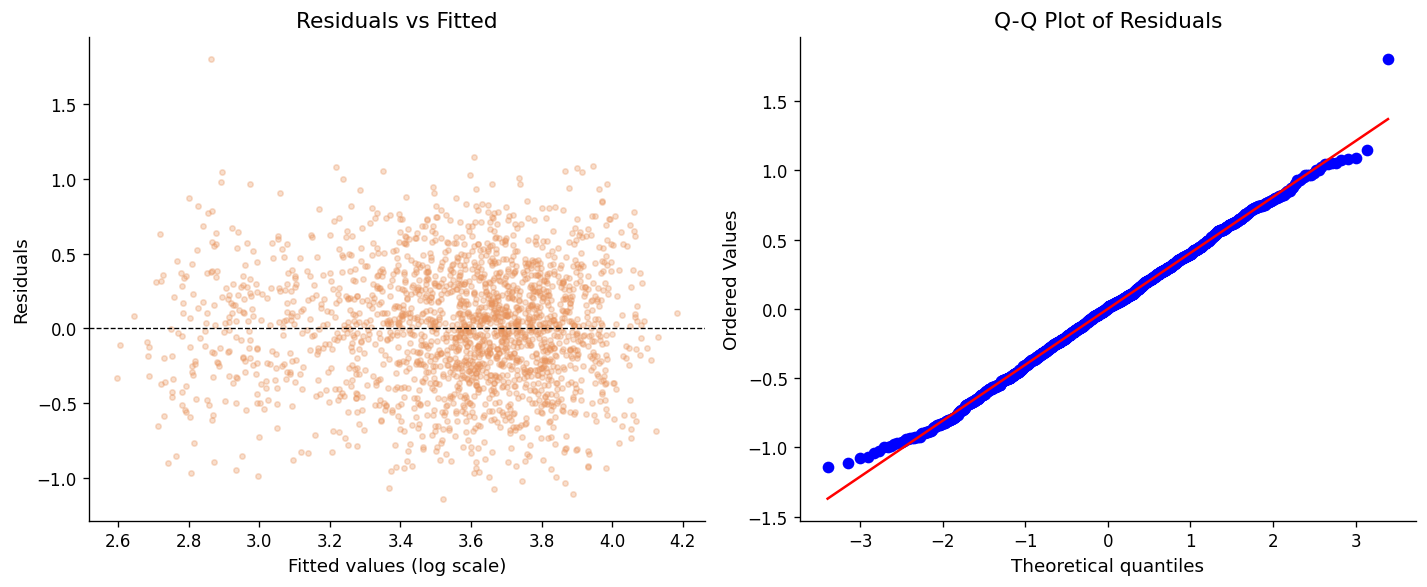

In [24]:
fitted  = model_ols.fittedvalues
resid   = model_ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Check for homoscedasticity
axes[0].scatter(fitted, resid, alpha=0.3, s=10, color=ACCENT)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted values (log scale)')
axes[0].set_ylabel('Residuals')

# Check for normality of errors
stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()


**Your interpretation (A3.2):**

The residuals vs fitted plot shows points scattered evenly around zero across all fitted values, with no funnel shape or curve, so the constant-variance (homoscedasticity) assumption holds. The Q-Q plot shows the residuals following the normal line closely, with only small deviation at the far tails. The near-zero skewness (0.014) and near-zero excess kurtosis (−0.09) from the model summary back this up, and the Jarque-Bera test (p = 0.68) does not reject normality. Overall the diagnostics look fine: the OLS assumptions of normal, constant-variance errors are well met on the log outcome scale.

### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

I am testing the interaction between ab_group and prior_whiteboard_sessions, to see whether the AI assistant helps new users or experienced users more.

I expect the AI assistant to help new users (those with fewer prior sessions) more than experienced users. New users do not yet know the tool well, so the AI can guide them, suggest next steps, and lower the learning curve. Experienced users already have their own workflow, so the AI adds less on top of what they can already do. If this is right, the AI's effect on session duration should be larger when prior_whiteboard_sessions is low and smaller when it is high, which would show up as a negative interaction coefficient (treatment effect shrinks as prior sessions increase).


In [25]:
# Step 1: Create the interaction term (ab_group_bin x log_prior_whiteboard_sessions)
interaction = (df_ab['ab_group_bin'] * df_ab['log_prior_whiteboard_sessions']).rename('ab_x_log_prior')

# Step 2: Append to the feature matrix and refit OLS
X_interact = pd.concat([X, interaction], axis=1)
model_interact = sm.OLS(y, sm.add_constant(X_interact)).fit()
print(model_interact.summary())


                                     OLS Regression Results                                    
Dep. Variable:     avg_whiteboard_session_duration_min   R-squared:                       0.363
Model:                                             OLS   Adj. R-squared:                  0.359
Method:                                  Least Squares   F-statistic:                     102.9
Date:                                 Sat, 27 Jun 2026   Prob (F-statistic):          1.97e-185
Time:                                         18:07:38   Log-Likelihood:                -1020.9
No. Observations:                                 2000   AIC:                             2066.
Df Residuals:                                     1988   BIC:                             2133.
Df Model:                                           11                                         
Covariance Type:                             nonrobust                                         
                                    coef

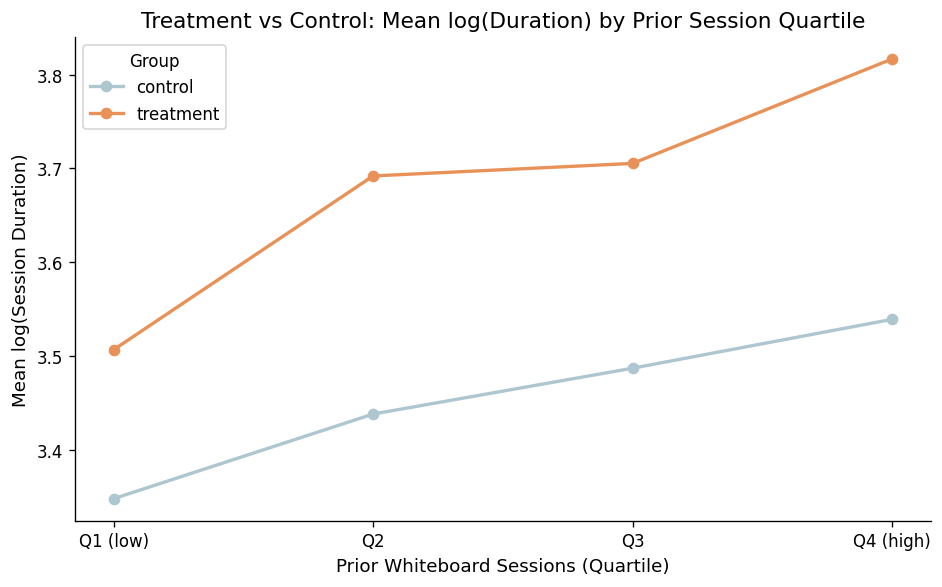

Interaction (ab_x_log_prior): coef=0.0466, p=0.0909


In [26]:
# Bin prior_whiteboard_sessions into quartiles and compare treatment vs control means
df_plot = df_ab.copy()
df_plot['prior_bin'] = pd.qcut(df_plot['prior_whiteboard_sessions'], q=4,
                                labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
df_plot['log_duration'] = y

means = (df_plot.groupby(['prior_bin', 'ab_group'], observed=True)['log_duration']
         .mean().reset_index())

fig, ax = plt.subplots(figsize=(8, 5))
for group, colour in [('control', '#aec6cf'), ('treatment', ACCENT)]:
    sub = means[means['ab_group'] == group]
    ax.plot(sub['prior_bin'].astype(str), sub['log_duration'],
            marker='o', label=group, color=colour, linewidth=2)

ax.set_title('Treatment vs Control: Mean log(Duration) by Prior Session Quartile')
ax.set_xlabel('Prior Whiteboard Sessions (Quartile)')
ax.set_ylabel('Mean log(Session Duration)')
ax.legend(title='Group')
plt.tight_layout()
plt.show()

# Print key interaction coefficient
c = model_interact.params['ab_x_log_prior']
p = model_interact.pvalues['ab_x_log_prior']
print(f'Interaction (ab_x_log_prior): coef={c:.4f}, p={p:.4f}')


**Your interpretation (A4):**

My hypothesis predicted a negative interaction: that the AI assistant would help newer users (low prior_whiteboard_sessions) more than experienced users, so the treatment effect would shrink as prior experience increases. The data did not support this. The interaction coefficient for ab_x_log_prior (ab_group_bin × log_prior_whiteboard_sessions) is +0.047 (p = 0.091), which points the opposite way: the treatment effect is slightly larger for users with more prior sessions, not fewer. It also does not reach statistical significance (p > 0.05). The line plot hints at a slightly widening gap between treatment and control at higher experience quartiles, which matches the positive coefficient, but the effect is weak and could easily be noise. One possible reason is that experienced users already have a workflow and can fold AI suggestions into it to extend their sessions, while brand-new users may not yet know how to use the AI well. For Phigma's rollout, this suggests the AI assistant gives a fairly even benefit across experience levels, and there is no strong evidence that targeting one group over another would change its impact much.


---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [27]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


Shape: (3000, 15)

Column types:
user_id                         object
signup_date                     object
first_session_date              object
device_type                     object
country_tier                    object
referral_source                 object
num_sessions_30d                 int64
total_time_min_30d               int64
projects_created_30d             int64
exports_30d                      int64
collaborators_invited_30d        int64
support_tickets_30d              int64
used_premium_feature_preview     int64
ai_assistant_sessions_30d        int64
subscribed                       int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [28]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [29]:
# 1. Parse dates
df_sub['signup_date']       = pd.to_datetime(df_sub['signup_date'])
df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. Days from signup to first session
df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. Average session duration — guard against divide-by-zero
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] > 0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d'],
    0
)

# 4. Weekend signup flag
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
device_dummies2  = pd.get_dummies(df_sub['device_type'],     prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref',    drop_first=True)

# 7. Ordinal-encode country_tier (tier_1=1, tier_2=2, tier_3=3)
df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1': 1, 'tier_2': 2, 'tier_3': 3})

# 8. Assemble final feature matrix
num_cols_sub = ['days_to_first_session', 'avg_session_duration_min',
                'num_sessions_30d', 'projects_created_30d', 'exports_30d',
                'collaborators_invited_30d', 'support_tickets_30d',
                'used_premium_feature_preview', 'ai_assistant_sessions_30d',
                'is_weekend_signup', 'country_tier_enc']

X_sub = pd.concat(
    [df_sub[num_cols_sub], device_dummies2, referral_dummies],
    axis=1
).astype(float)

y_sub = df_sub['subscribed']

# Confirm
print(f"Any inf: {np.isinf(X_sub.values).any()}")
print(f"Any NaN: {X_sub.isnull().any().any()}")
print(f"Feature matrix shape: {X_sub.shape}")
X_sub.head(3)


Any inf: False
Any NaN: False
Feature matrix shape: (3000, 16)


,days_to_first_session,avg_session_duration_min,num_sessions_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,5.0,96.0000,1.0,1.0,0.0,0.0,0.0,1.0,6.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,17.8000,15.0,8.0,1.0,5.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0
2,14.0,16.4375,16.0,0.0,0.0,3.0,3.0,1.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**Your interpretation (B1):**

- **days_to_first_session**: users who take longer to start their first session may be less engaged and therefore less likely to subscribe.
- **avg_session_duration_min**: longer average sessions indicate deeper product engagement, a strong proxy for perceived value and conversion intent. Computed as total_time_min_30d / num_sessions_30d; the divide-by-zero guard sets the value to 0 for users with zero sessions (none exist in this dataset, but the guard ensures robustness).
- **num_sessions_30d**: frequency of use reflects habit formation; users who return often are more likely to see enough value to pay.
- **projects_created_30d**: creating projects is a high-intent action indicating the user is actively building, not just browsing.
- **exports_30d**: exporting outputs signals the user is extracting tangible value from the product.
- **collaborators_invited_30d**: inviting collaborators increases switching costs and reflects organizational buy-in, both of which predict conversion.
- **support_tickets_30d**: may predict subscription positively (engaged users hitting feature limits) or negatively (frustrated users); left in as an empirical question.
- **used_premium_feature_preview**: direct exposure to premium features is a strong conversion lever; users who try them know what they would be paying for.
- **ai_assistant_sessions_30d**: AI assistant usage signals deep engagement and comfort with advanced features that are gated behind the paid tier.
- **is_weekend_signup**: weekend vs weekday signup may distinguish hobbyists from professionals, who differ in subscription propensity.
- **country_tier_enc**: ordinal encoding (tier_1 = 1, tier_2 = 2, tier_3 = 3) is justified because the tiers reflect purchasing-power markets with a natural ordering; higher-numbered tiers are less likely to convert at USD pricing.
- **device_mobile, device_tablet**: one-hot dummies for `device_type` (desktop is the dropped reference); mobile/tablet users may have lower conversion rates due to limited-capability sessions.
- **ref_paid_ad, ref_referral, ref_social**: one-hot dummies for `referral_source` (organic is the dropped reference); acquisition channel predicts intent and willingness to pay.


### B2 — EDA for Subscription


In [31]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


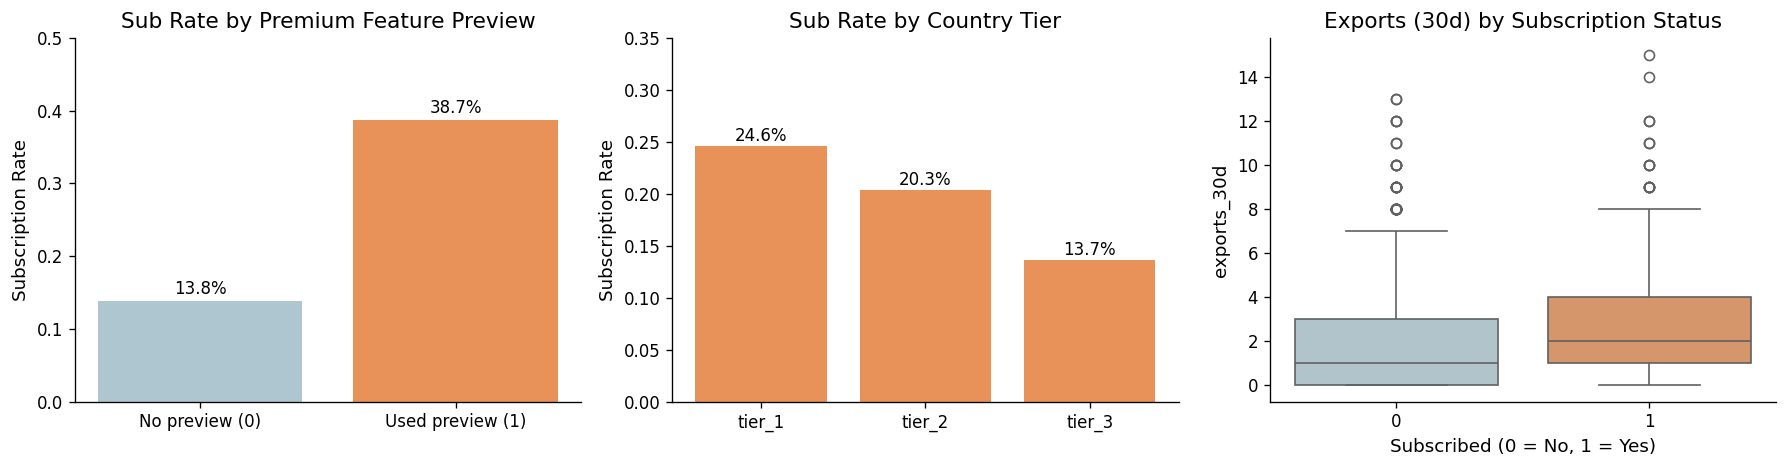

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: subscription rate by used_premium_feature_preview
rates_premium = df_sub.groupby('used_premium_feature_preview')['subscribed'].mean()
axes[0].bar(['No preview (0)', 'Used preview (1)'], rates_premium.values, color=['#aec6cf', ACCENT])
axes[0].set_title('Sub Rate by Premium Feature Preview')
axes[0].set_ylabel('Subscription Rate')
axes[0].set_ylim(0, 0.5)
for bar, val in zip(axes[0].patches, rates_premium.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.1%}", ha="center", fontsize=10)

# Plot 2: subscription rate by country_tier
rates_tier = df_sub.groupby('country_tier')['subscribed'].mean().reindex(['tier_1','tier_2','tier_3'])
axes[1].bar(rates_tier.index, rates_tier.values, color=ACCENT)
axes[1].set_title('Sub Rate by Country Tier')
axes[1].set_ylabel('Subscription Rate')
axes[1].set_ylim(0, 0.35)
for bar, val in zip(axes[1].patches, rates_tier.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f"{val:.1%}", ha="center", fontsize=10)

# Plot 3: exports_30d distribution by subscription status
sns.boxplot(data=df_sub, x='subscribed', y='exports_30d',
            palette={'0': '#aec6cf', '1': ACCENT}, ax=axes[2])
axes[2].set_title('Exports (30d) by Subscription Status')
axes[2].set_xlabel('Subscribed (0 = No, 1 = Yes)')
axes[2].set_ylabel('exports_30d')

plt.tight_layout()
plt.show()


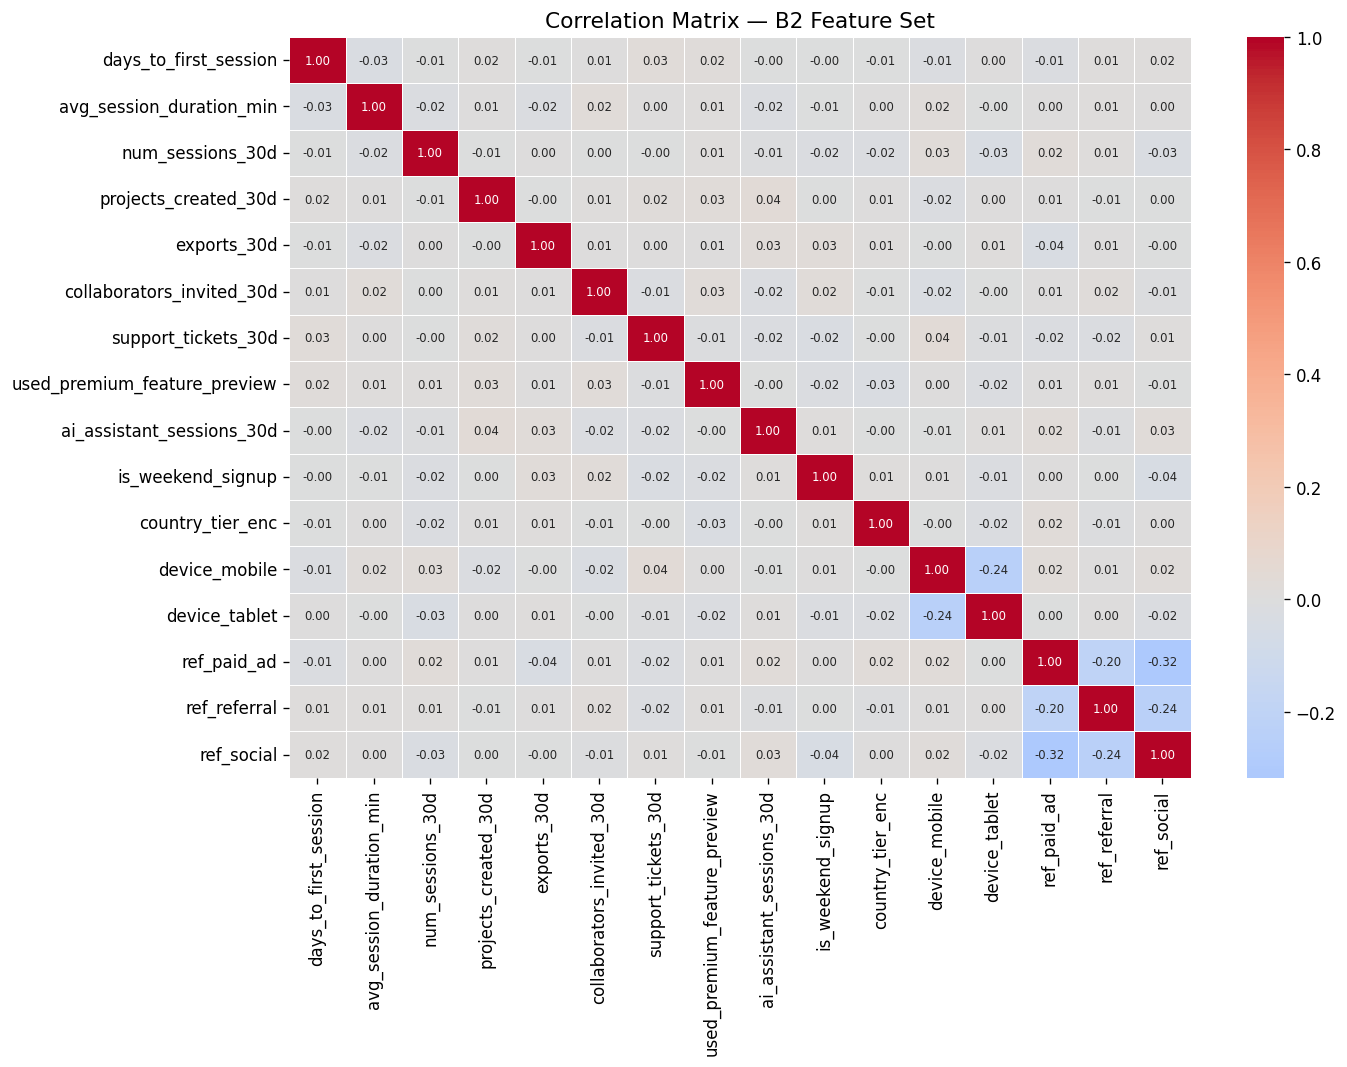

In [34]:
numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
corr = X_sub[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title('Correlation Matrix — B2 Feature Set')
plt.tight_layout()
plt.show()


In [38]:
corr_with_y = X_sub.corrwith(df_sub['subscribed']).sort_values()
print(corr_with_y)

days_to_first_session          -1.151436e-01
country_tier_enc               -1.015232e-01
ref_paid_ad                    -3.952548e-02
device_tablet                  -2.972731e-02
device_mobile                  -1.546721e-03
projects_created_30d           -5.762399e-17
is_weekend_signup               4.890667e-03
ref_social                      6.396182e-03
ai_assistant_sessions_30d       2.041977e-02
ref_referral                    3.273521e-02
num_sessions_30d                3.819872e-02
support_tickets_30d             5.461930e-02
collaborators_invited_30d       5.554592e-02
avg_session_duration_min        7.183258e-02
exports_30d                     1.628785e-01
used_premium_feature_preview    2.762332e-01
dtype: float64


**Your interpretation (B2):**

used_premium_feature_preview is the feature most strongly linked to subscription: users who previewed a premium feature subscribed at 38.7% versus 13.8% for those who did not, almost a 3x difference, making it the clearest conversion signal in the data. country_tier shows a steady downward gradient (tier_1: 24.6%, tier_2: 20.3%, tier_3: 13.7%), which fits the idea that higher purchasing power in tier_1 markets leads to more willingness to pay. exports_30d has the second-strongest link among the numeric features (r = 0.163, behind only used_premium_feature_preview), and its boxplot shows a higher median for subscribers, so users who produce real outputs are more likely to convert. days_to_first_session is negative in a surprising way (r = −0.115): users who start sooner after signing up convert more, probably because quick engagement reflects real intent rather than casual curiosity. No pair of numeric features is highly correlated (all |r| < 0.4 in the heatmap), so multicollinearity is not a problem for the logistic regression.


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [40]:
X_const_sub = sm.add_constant(X_sub)
model_logit = sm.Logit(y_sub, X_const_sub).fit()
print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.440669
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2983
Method:                           MLE   Df Model:                           16
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1389
Time:                        19:13:08   Log-Likelihood:                -1322.0
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 1.039e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.3413      0.259     -9.036      0.000

In [41]:
# Compute odds ratios and CIs for significant predictors (p < 0.05)
odds_ratios = np.exp(model_logit.params)
conf_int    = np.exp(model_logit.conf_int())
conf_int.columns = ['OR_lower', 'OR_upper']

or_table = pd.concat([odds_ratios.rename('OR'), conf_int, model_logit.pvalues.rename('p_value')], axis=1)
or_table = or_table[or_table['p_value'] < 0.05].drop('const', errors='ignore')
or_table = or_table.sort_values('OR', ascending=False).round(4)
print(or_table)


                                  OR  OR_lower  OR_upper  p_value
used_premium_feature_preview  4.3394    3.5687    5.2766   0.0000
exports_30d                   1.2146    1.1636    1.2677   0.0000
support_tickets_30d           1.1692    1.0746    1.2722   0.0003
collaborators_invited_30d     1.0629    1.0175    1.1103   0.0061
avg_session_duration_min      1.0236    1.0116    1.0357   0.0001
days_to_first_session         0.9119    0.8877    0.9368   0.0000
country_tier_enc              0.7007    0.6164    0.7965   0.0000


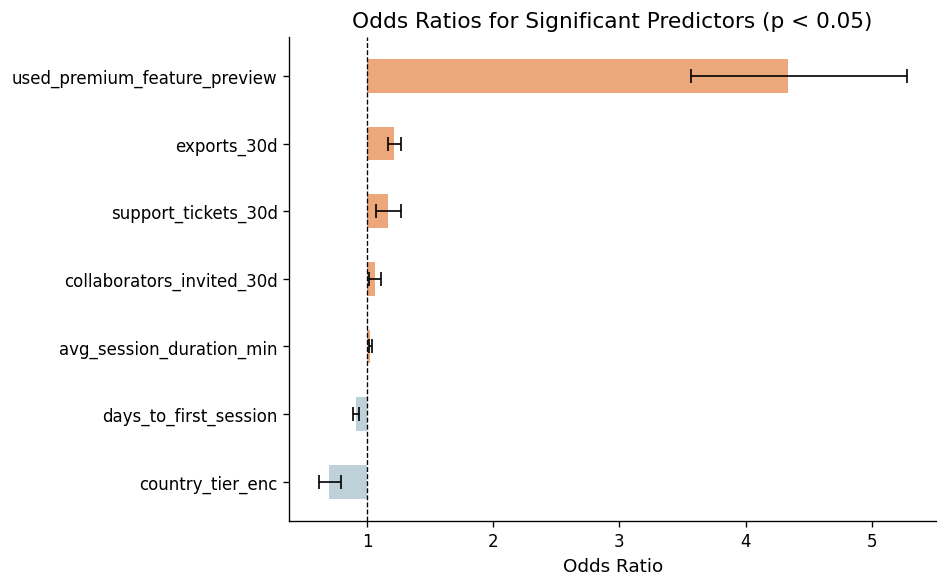

In [42]:
# Forest plot of odds ratios for significant predictors
sig_mask = model_logit.pvalues < 0.05
sig_mask = sig_mask[sig_mask].index.drop('const', errors='ignore')

ors   = np.exp(model_logit.params[sig_mask])
ci_lo = np.exp(model_logit.conf_int().loc[sig_mask, 0])
ci_hi = np.exp(model_logit.conf_int().loc[sig_mask, 1])
ors_sorted = ors.sort_values()
ci_lo = ci_lo[ors_sorted.index]
ci_hi = ci_hi[ors_sorted.index]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(ors_sorted))
ax.barh(list(y_pos), ors_sorted.values - 1,
        left=1, color=[ACCENT if v > 1 else "#aec6cf" for v in ors_sorted.values],
        alpha=0.8, height=0.5)
ax.errorbar(ors_sorted.values, list(y_pos),
            xerr=[ors_sorted.values - ci_lo.values, ci_hi.values - ors_sorted.values],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(ors_sorted.index)
ax.set_xlabel('Odds Ratio')
ax.set_title('Odds Ratios for Significant Predictors (p < 0.05)')
plt.tight_layout()
plt.show()


**Results paragraph (B3):**

The logistic regression ran successfully on all 3,000 users (McFadden pseudo R² = 0.139, LLR p < 10⁻⁸⁰). used_premium_feature_preview is by far the strongest predictor: users who previewed a premium feature were 4.34x more likely to subscribe (OR = 4.34, 95% CI [3.57, 5.28], p < 0.001), which fits the idea that trying a paid feature pushes people toward converting. exports_30d has an OR of 1.22 (p < 0.001), so each extra export in the 30 days raises the odds of subscribing by about 22%, since people who export a lot are getting real value out of the product. days_to_first_session has an OR of 0.91 (p < 0.001): each extra day between signing up and first use lowers the odds of subscribing by about 9%, so people who start sooner are more likely to convert. country_tier_enc has an OR of 0.70 (p < 0.001), so each step down in market tier toward lower purchasing power lowers the odds by about 30%. The surprising result is support_tickets_30d (OR = 1.17, p < 0.001): more support tickets go with a higher chance of subscribing, not lower as we might expect. The likely reason is that people who file tickets are heavily engaged and have run into limits while seriously considering the paid tier, so the tickets signal interest rather than unhappiness. Since this is observational data, it is also possible that tickets and subscribing are both just driven by heavy usage, rather than tickets causing conversion.


### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
# fig, ax = plt.subplots(figsize=(5, 4))
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.title('Logistic Regression — Confusion Matrix')
# plt.show()


In [ ]:
# YOUR CODE HERE
# Classification report
# print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8)
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve — Logistic Regression')
# ax.legend()
# plt.show()


**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


In [ ]:
# YOUR CODE HERE
# Confusion matrix


In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)


### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)


In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
